# Object Tracking Overview

- **Object detection** answers: *"what is where?"* in a **single frame**
- **Object tracking** answers: *"which detection in frame $t$ is the same object in frame $t+1$?"*
- The core challenge is maintaining **consistent identities** across time
- Detection is **spatial**. Tracking is **spatiotemporal identity**.

## Tracking vs Detection

| Task | Output | Scope |
|------|--------|-------|
| Detection | Bounding boxes per frame | Single frame |
| Tracking | Bounding boxes with **consistent IDs** | Across time |

Consider two frames of video:

- **Frame 1**: Person A is on the left, Person B is on the right
- **Frame 2**: The two people have swapped positions

A detector will find two people in both frames. But only a *tracker* can tell you which person is which — that is the **identity association** problem.

## Single-Object Tracking (SOT) vs Multi-Object Tracking (MOT)

:::: {.columns}
::: {.column width="50%"}
**Single-Object Tracking (SOT)**

- Given a bounding box in frame 1, follow **that one target** through the video
- Use cases:
  - Surveillance zoom-in on a suspect
  - Sports player highlight reel
  - Drone follow-mode
:::
::: {.column width="50%"}
**Multi-Object Tracking (MOT)**

- Detect and track **all objects** of interest across every frame
- Use cases:
  - Autonomous driving (track all vehicles and pedestrians)
  - Crowd analysis
  - Retail analytics
:::
::::

This lecture focuses primarily on **MOT** — the harder, more general problem.

## Why Tracking Is Hard

- **Occlusion**: objects disappear behind others or leave the frame entirely
- **Appearance changes**: lighting shifts, pose changes, deformation
- **Camera motion**: ego-motion (the camera moves) vs object motion
- **Scale changes**: objects approach or recede from the camera
- **Crowded scenes**: many similar-looking objects in close proximity

# Datasets

| Aspect       | SOT             | MOT                  |
| ------------ | --------------- | -------------------- |
| Input        | One bbox        | Many detections      |
| Core problem | Localization    | Identity association |
| Benchmark    | OTB, LaSOT, VOT | MOTChallenge         |
| Metrics      | IoU, precision  | MOTA, ID switches    |

We will use a few sequences from the **OTB (Object Tracking Benchmark)** throughout this lecture. Each sequence is a folder of numbered frames (`img/*.jpg`) plus a `groundtruth_rect.txt` file with one bounding box per frame.

| Sequence | Challenge | Good demo for |
|----------|-----------|---------------|
| **Car1** | Illumination, scale | Baseline tracker, optical flow |
| **CarScale** | Large scale change | Kalman filter limits, adaptive trackers |
| **David** | Illumination change, pose | Mean-shift, Siamese trackers |
| **Jumping** | Fast motion, motion blur | Failure analysis, comparing trackers |


In [4]:
%%bash
BASE_URL="https://web.archive.org/web/http://cvlab.hanyang.ac.kr/tracker_benchmark/seq"
DATA_DIR="$HOME/data/OTB"
SEQUENCES="Car1 CarScale David Jumping"

mkdir -p "$DATA_DIR"

for SEQ in $SEQUENCES; do
    if [ -d "$DATA_DIR/$SEQ" ]; then
        echo "$SEQ already exists, skipping"
        continue
    fi
    echo "Downloading $SEQ..."
    curl -fSL "$BASE_URL/$SEQ.zip" -o "$DATA_DIR/$SEQ.zip" 2>/dev/null
    if ! file "$DATA_DIR/$SEQ.zip" | grep -q "Zip archive"; then
        echo "  FAILED: $SEQ.zip is not a valid zip, skipping"
        rm -f "$DATA_DIR/$SEQ.zip"
        continue
    fi
    unzip -qo "$DATA_DIR/$SEQ.zip" -d "$DATA_DIR" -x "__MACOSX/*"
    rm "$DATA_DIR/$SEQ.zip"
    echo "  $SEQ: $(ls "$DATA_DIR/$SEQ/img" | wc -l) frames"
done

rm -rf "$DATA_DIR/__MACOSX" 2>/dev/null
echo ""
echo "Done! Sequences saved to $DATA_DIR"
ls "$DATA_DIR"

  Car1: 1020 frames


caution: excluded filename not matched:  __MACOSX/*


  CarScale: 253 frames


caution: excluded filename not matched:  __MACOSX/*


  David: 770 frames


caution: excluded filename not matched:  __MACOSX/*


  Jumping: 313 frames

Done! Sequences saved to /home/ben/data/OTB
Car1
CarScale
David
Jumping


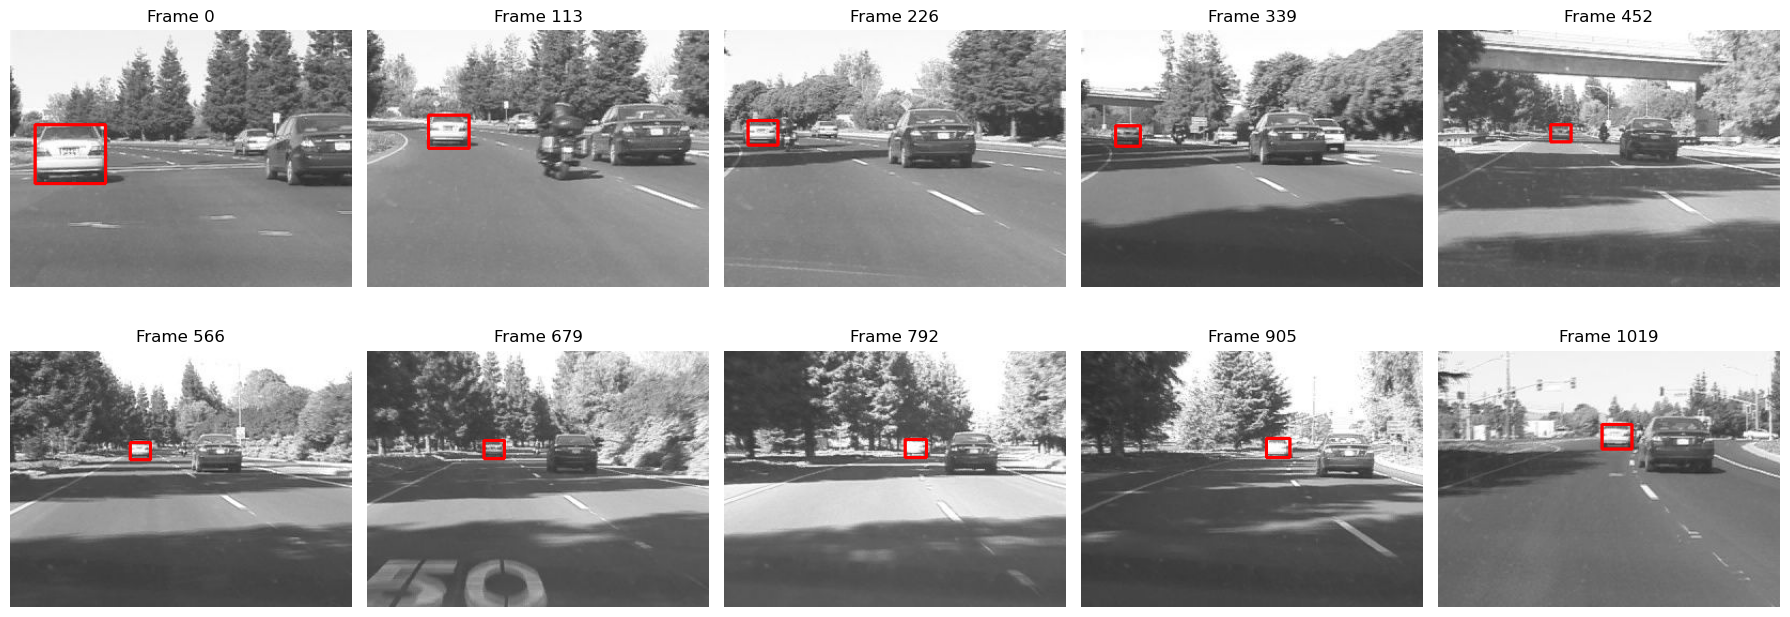

In [5]:
# Read in the OTB dataset and play frames with gif player


from pathlib import Path
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the path to the OTB dataset
otb_path = Path("/home/ben/data/OTB")

# Get car sequence path
car_seq = [path for path in otb_path.iterdir() if path.name == "Car1"][0]

# Load frames in sorted order
frame_paths = sorted((car_seq / "img").glob("*.jpg"))

# Load ground truth (handles both comma and tab delimiters)
lines = (car_seq / "groundtruth_rect.txt").read_text().strip().split("\n")
gt = np.array([[float(x) for x in re.split(r'[,\t\s]+', line)] for line in lines])

# Save the car sequence frames
frames = []

# Draw bounding boxes
frames = []
for i, frame_path in enumerate(frame_paths):
    frame = cv2.imread(str(frame_path))
    x, y, w, h = gt[i].astype(int)
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Show a few samples
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, idx in zip(axes.flat, np.linspace(0, len(frames)-1, 10, dtype=int)):
    ax.imshow(frames[idx])
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()



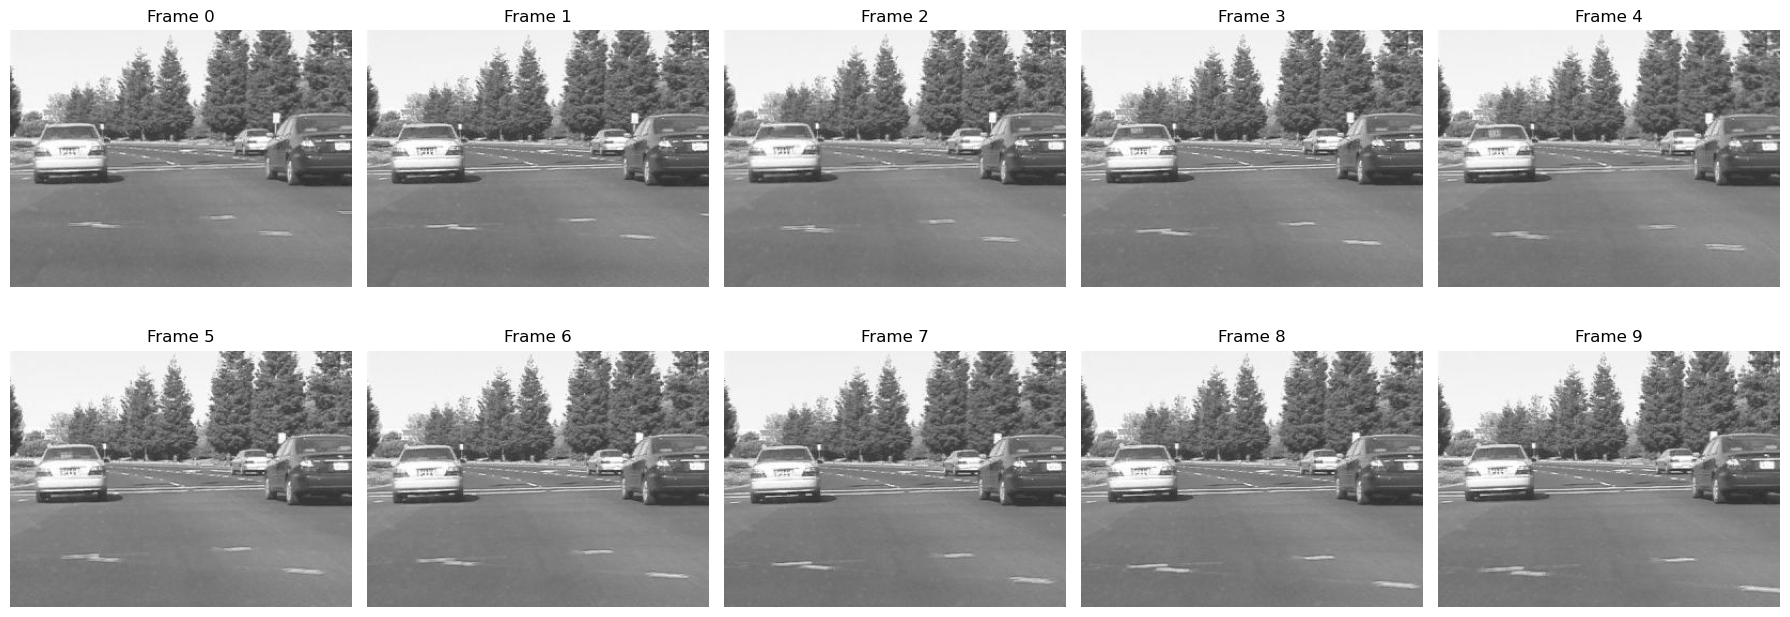

In [8]:
# Plot the first 8 frames

from pathlib import Path
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the path to the OTB dataset
otb_path = Path("/home/ben/data/OTB")

# Get car sequence path
car_seq = [path for path in otb_path.iterdir() if path.name == "Car1"][0]

# Load frames in sorted order
frame_paths = sorted((car_seq / "img").glob("*.jpg"))

# Load ground truth (handles both comma and tab delimiters)
lines = (car_seq / "groundtruth_rect.txt").read_text().strip().split("\n")
gt = np.array([[float(x) for x in re.split(r'[,\t\s]+', line)] for line in lines])

# Save the car sequence frames
frames = []

# Draw bounding boxes
frames = []
for i, frame_path in enumerate(frame_paths):
    frame = cv2.imread(str(frame_path))
    x, y, w, h = gt[i].astype(int)
    # cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Show a few samples
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, idx in zip(axes.flat, range(10)):
    ax.imshow(frames[idx])
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Classical Tracking Foundations

## Optical Flow

- Estimates **per-pixel motion** between consecutive frames
- For each pixel, compute the displacement vector $(dx, dy)$ that maps it from frame $t$ to frame $t+1$
- Useful as a **motion cue** for tracking, but not a complete tracker by itself

## Optical Flow: Brightness Constancy

**Goal of optical flow**: given two consecutive video frames, compute a motion vector $(dx, dy)$ for each pixel: *where did this pixel move?*

The fundamental assumption that makes this possible is **brightness constancy**:

$$I(x, y, t) = I(x + dx, y + dy, t + dt)$$

- $I(x, y, t)$: the pixel intensity (brightness) at position $(x, y)$ in frame $t$
- $(dx, dy)$: the displacement of that pixel between frame $t$ and frame $t + dt$
- The equation says: a pixel's brightness **does not change** when it moves, only its position changes

By taking a first-order Taylor expansion of the right side and simplifying, we get the **optical flow constraint equation**:

$$I_x \cdot u + I_y \cdot v + I_t = 0$$

- $I_x, I_y$: spatial image gradients (how brightness changes across the image in $x$ and $y$)
- $I_t$: temporal gradient (how brightness changes between frames at the same location)
- $(u, v)$: the optical flow vector we want to solve for (horizontal and vertical velocity of the pixel)

The euqation above says: "the brightness I lost because the object slid away must equal the brightness I gained from whatever slid in." We can measure $$

This is **one equation with two unknowns** $(u, v)$, so it cannot be solved for a single pixel alone. Different methods handle this differently:

## Optical Flow Methods

- **Lucas-Kanade** (sparse): assumes all pixels in a small neighborhood share the same flow $(u, v)$. This gives enough equations to solve the system. Only computes flow at selected keypoints — fast.
- **Farneback** (dense): fits a polynomial to the local neighborhood in each frame, then estimates flow from how the polynomial coefficients change. Computes flow for **every pixel** — slower but gives a complete motion field.

**Limitations**: brightness constancy is an approximation. It breaks down under lighting changes, reflections, shadows, transparent objects, and large displacements (where the Taylor approximation is inaccurate).

## Optical Flow Demo {.scrollable}

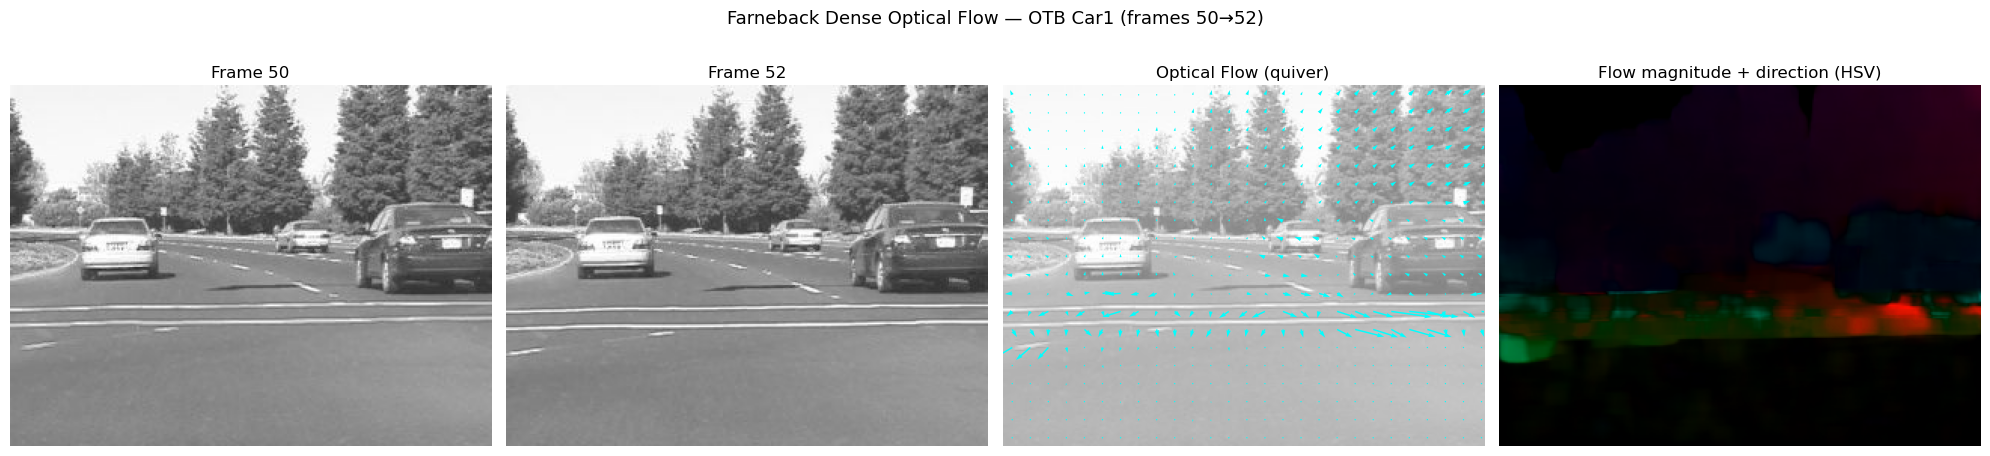

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

car_seq = Path.home() / "data" / "OTB" / "Car1" / "img"
frame_paths = sorted(car_seq.glob("*.jpg"))

# Pick two frames a few apart so the motion is visible
idx_a, idx_b = 50, 52
gray1 = cv2.imread(str(frame_paths[idx_a]), cv2.IMREAD_GRAYSCALE)
gray2 = cv2.imread(str(frame_paths[idx_b]), cv2.IMREAD_GRAYSCALE)
color1 = cv2.cvtColor(cv2.imread(str(frame_paths[idx_a])), cv2.COLOR_BGR2RGB)

flow = cv2.calcOpticalFlowFarneback(
    gray1, gray2, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2, flags=0
)

# Flow magnitude + angle for the HSV visualization
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
hsv = np.zeros((*gray1.shape, 3), dtype=np.uint8)
hsv[..., 0] = ang * 180 / np.pi / 2   # hue = direction
hsv[..., 1] = 255                       # full saturation
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)  # brightness = speed
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(color1)
axes[0].set_title(f'Frame {idx_a}')

axes[1].imshow(cv2.cvtColor(cv2.imread(str(frame_paths[idx_b])), cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Frame {idx_b}')

# Quiver plot
step = 12
h, w = gray1.shape
y_grid, x_grid = np.mgrid[step//2:h:step, step//2:w:step]
axes[2].imshow(color1, alpha=0.6)
axes[2].quiver(
    x_grid, y_grid,
    flow[step//2::step, step//2::step, 0],
    -flow[step//2::step, step//2::step, 1],
    color='cyan', scale=150, width=0.003
)
axes[2].set_title('Optical Flow (quiver)')

# HSV visualization
axes[3].imshow(flow_rgb)
axes[3].set_title('Flow magnitude + direction (HSV)')

for ax in axes:
    ax.axis('off')
plt.suptitle(f'Farneback Dense Optical Flow — OTB Car1 (frames {idx_a}→{idx_b})', fontsize=13)
plt.tight_layout()
plt.show()

## Tracking with Sparse Optical Flow (Lucas-Kanade) {.scrollable}

We know where the car is in frame 0 (from the ground truth bounding box). We can:

1. Detect **good features** (corners) inside that bounding box
2. Track those keypoints frame-to-frame using **Lucas-Kanade** (`cv2.calcOpticalFlowPyrLK`)
3. Draw their trajectories to visualize the car's path

This is a real classical tracker — no deep learning, just pixel motion.

Found 30 keypoints inside the car bbox


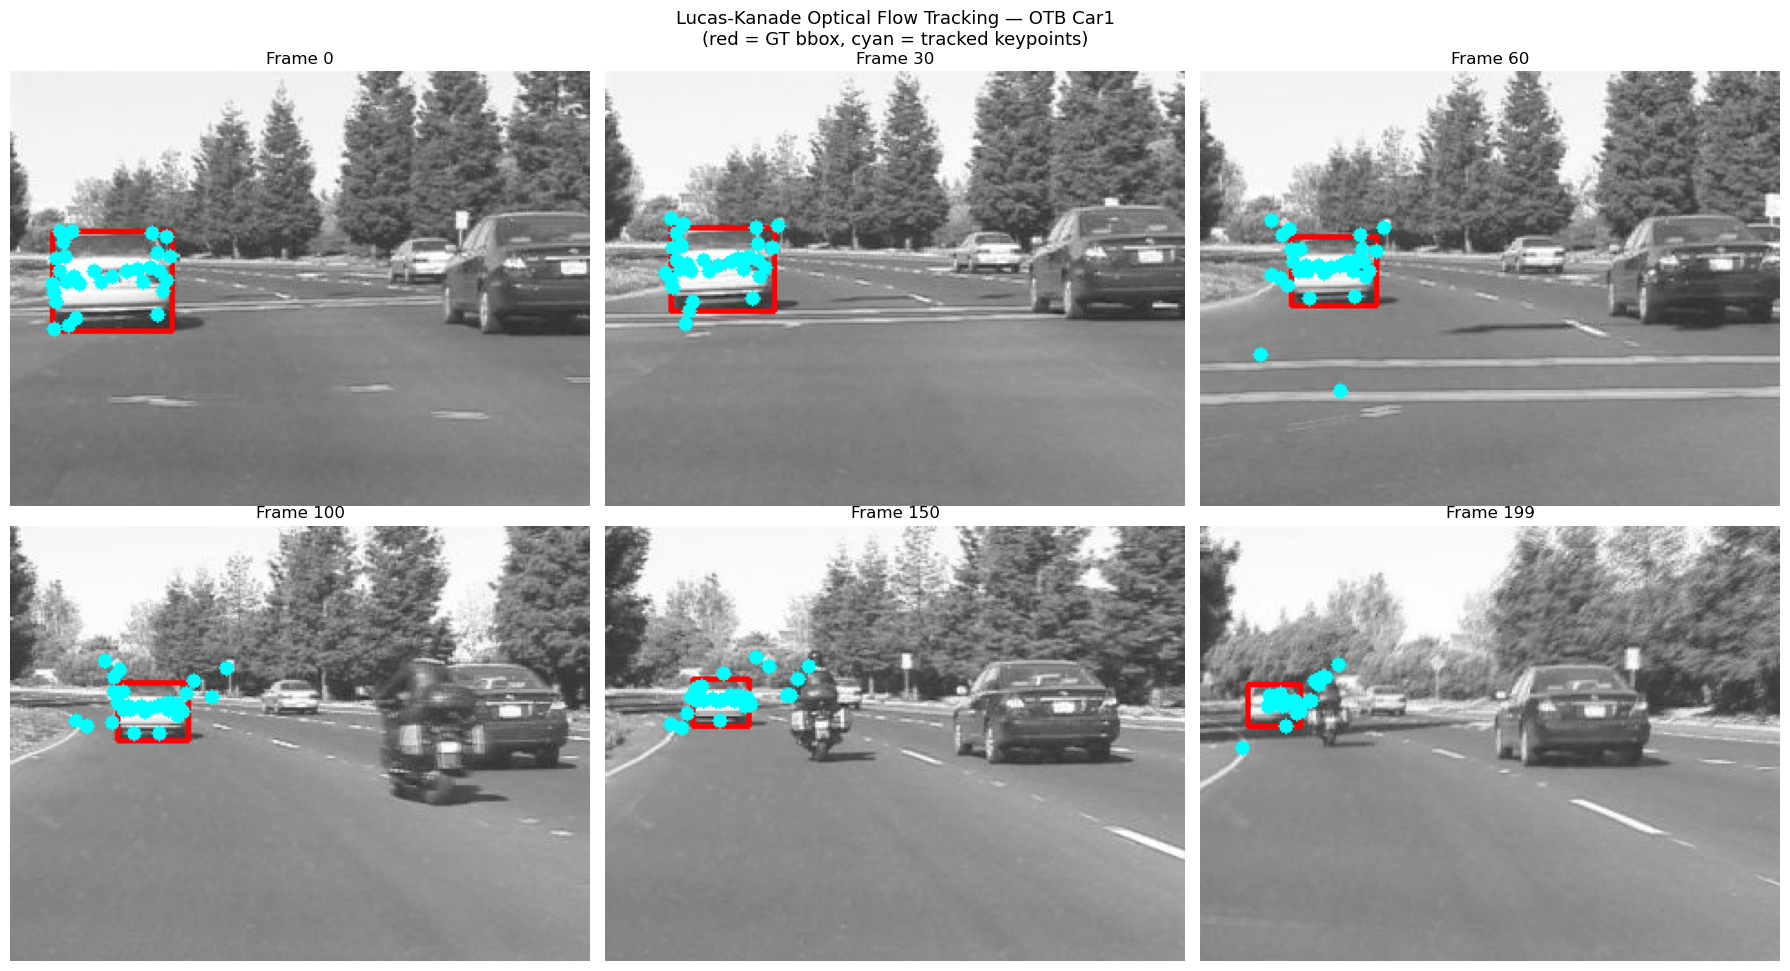

Tracked 30 keypoints across 200 frames


In [3]:
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seq_dir = Path.home() / "data" / "OTB" / "Car1"
frame_paths = sorted((seq_dir / "img").glob("*.jpg"))

# Load ground truth (handles comma / tab / space delimiters)
lines = (seq_dir / "groundtruth_rect.txt").read_text().strip().split("\n")
gt = np.array([[float(x) for x in re.split(r'[,\t\s]+', line)] for line in lines])

# Read first frame and get the car's bounding box
first_gray = cv2.imread(str(frame_paths[0]), cv2.IMREAD_GRAYSCALE)
x0, y0, w0, h0 = gt[0].astype(int)

# Create a mask so goodFeaturesToTrack only looks inside the bounding box
mask = np.zeros_like(first_gray)
mask[y0:y0+h0, x0:x0+w0] = 255

# Detect corners inside the car's bounding box
keypoints = cv2.goodFeaturesToTrack(
    first_gray, maxCorners=50, qualityLevel=0.05,
    minDistance=5, mask=mask
)
print(f"Found {len(keypoints)} keypoints inside the car bbox")

# Lucas-Kanade parameters
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

# Track across frames
n_frames = min(len(frame_paths), 200)
trajectories = {i: [tuple(keypoints[i][0])] for i in range(len(keypoints))}

prev_gray = first_gray
prev_pts = keypoints.copy()

for f_idx in range(1, n_frames):
    curr_gray = cv2.imread(str(frame_paths[f_idx]), cv2.IMREAD_GRAYSCALE)
    next_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, prev_pts, None, **lk_params
    )

    for i in range(len(status)):
        if status[i]:
            trajectories.setdefault(i, []).append(tuple(next_pts[i][0]))

    good_mask = status.flatten() == 1
    prev_pts = next_pts[good_mask].reshape(-1, 1, 2)
    prev_gray = curr_gray

# Visualize: show a few frames with tracked points + trails
sample_frames = [0, 30, 60, 100, 150, 199]
sample_frames = [f for f in sample_frames if f < n_frames]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, f_idx in zip(axes.flat, sample_frames):
    frame = cv2.cvtColor(cv2.imread(str(frame_paths[f_idx])), cv2.COLOR_BGR2RGB)

    # Draw gt bbox
    bx, by, bw, bh = gt[f_idx].astype(int)
    cv2.rectangle(frame, (bx, by), (bx+bw, by+bh), (255, 0, 0), 2)

    # Draw current keypoint positions only (no trails)
    for tid, trail in trajectories.items():
        if f_idx < len(trail):
            pt = tuple(map(int, trail[f_idx]))
            cv2.circle(frame, pt, 4, (0, 255, 255), -1)

    ax.imshow(frame)
    ax.set_title(f"Frame {f_idx}")
    ax.axis("off")

plt.suptitle("Lucas-Kanade Optical Flow Tracking — OTB Car1\n(red = GT bbox, cyan = tracked keypoints)", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Tracked {len(trajectories)} keypoints across {n_frames} frames")

## Kalman Filter

The Kalman filter is a recursive algorithm that estimates the state of a moving object from noisy observations.

**State vector**: $\mathbf{x} = [x, y, v_x, v_y]$ — position and velocity

**Two-step loop**:

1. **Predict**: propagate the state forward using a motion model (constant velocity)
   - "Where do I *expect* this object to be next frame?"
2. **Update**: correct the prediction when a new detection arrives
   - "How do I reconcile my prediction with what I actually detected?"

Handles noise and brief occlusions gracefully (during occlusion, just keep predicting).

**Limitations**: assumes linear motion and Gaussian noise — real objects don't always cooperate.

## Kalman Filter: Predict-Correct Loop

```{mermaid}
flowchart TD
    A["<b>Predict</b><br/>Use motion model to estimate next state<br/><i>x̂ = F · x + B · u</i>"] --> B{"New detection<br/>available?"}
    B -- Yes --> C["<b>Update</b><br/>Correct state with measurement<br/><i>x = x̂ + K · (z - H · x̂)</i>"]
    B -- "No (occluded)" --> D["<b>Coast</b><br/>Keep prediction as-is<br/><i>x = x̂</i>"]
    C --> E["Next frame"]
    D --> E
    E --> A

    style A fill:#4a90d9,color:#fff,stroke:#2c5f8a
    style B fill:#f5a623,color:#fff,stroke:#c47d12
    style C fill:#7ed321,color:#fff,stroke:#5a9a18
    style D fill:#d0021b,color:#fff,stroke:#9b0114
    style E fill:#9b9b9b,color:#fff,stroke:#6b6b6b
```

The filter balances **trust in the motion model** vs **trust in the measurement**, weighted by their respective uncertainties (the **Kalman gain** $K$).

- **Predict**: the motion model guesses the next state (position, velocity) — "where should the car be now?"
- **Update**: if a detection arrives, blend the prediction with the measurement — "ok, I predicted here, but I detected there, so the truth is somewhere in between"
- **Coast**: if no detection (occlusion), just trust the prediction — "I can't see it, but it was probably still moving the same way"

## Kalman Filter Tracking Demo (OTB Car1) {.scrollable}

We use `cv2.KalmanFilter` to track the car. The idea:

1. **Initialize** the Kalman state with the ground-truth bbox center from frame 0
2. Each frame, **predict** where the car should be
3. **Simulate a detector** by using the ground-truth bbox as the "measurement" (in a real system this would come from YOLO, Faster R-CNN, etc.)
4. **Correct** the Kalman state with the measurement
5. Compare the **prediction** (before correction) vs the **measurement** vs the **corrected estimate**

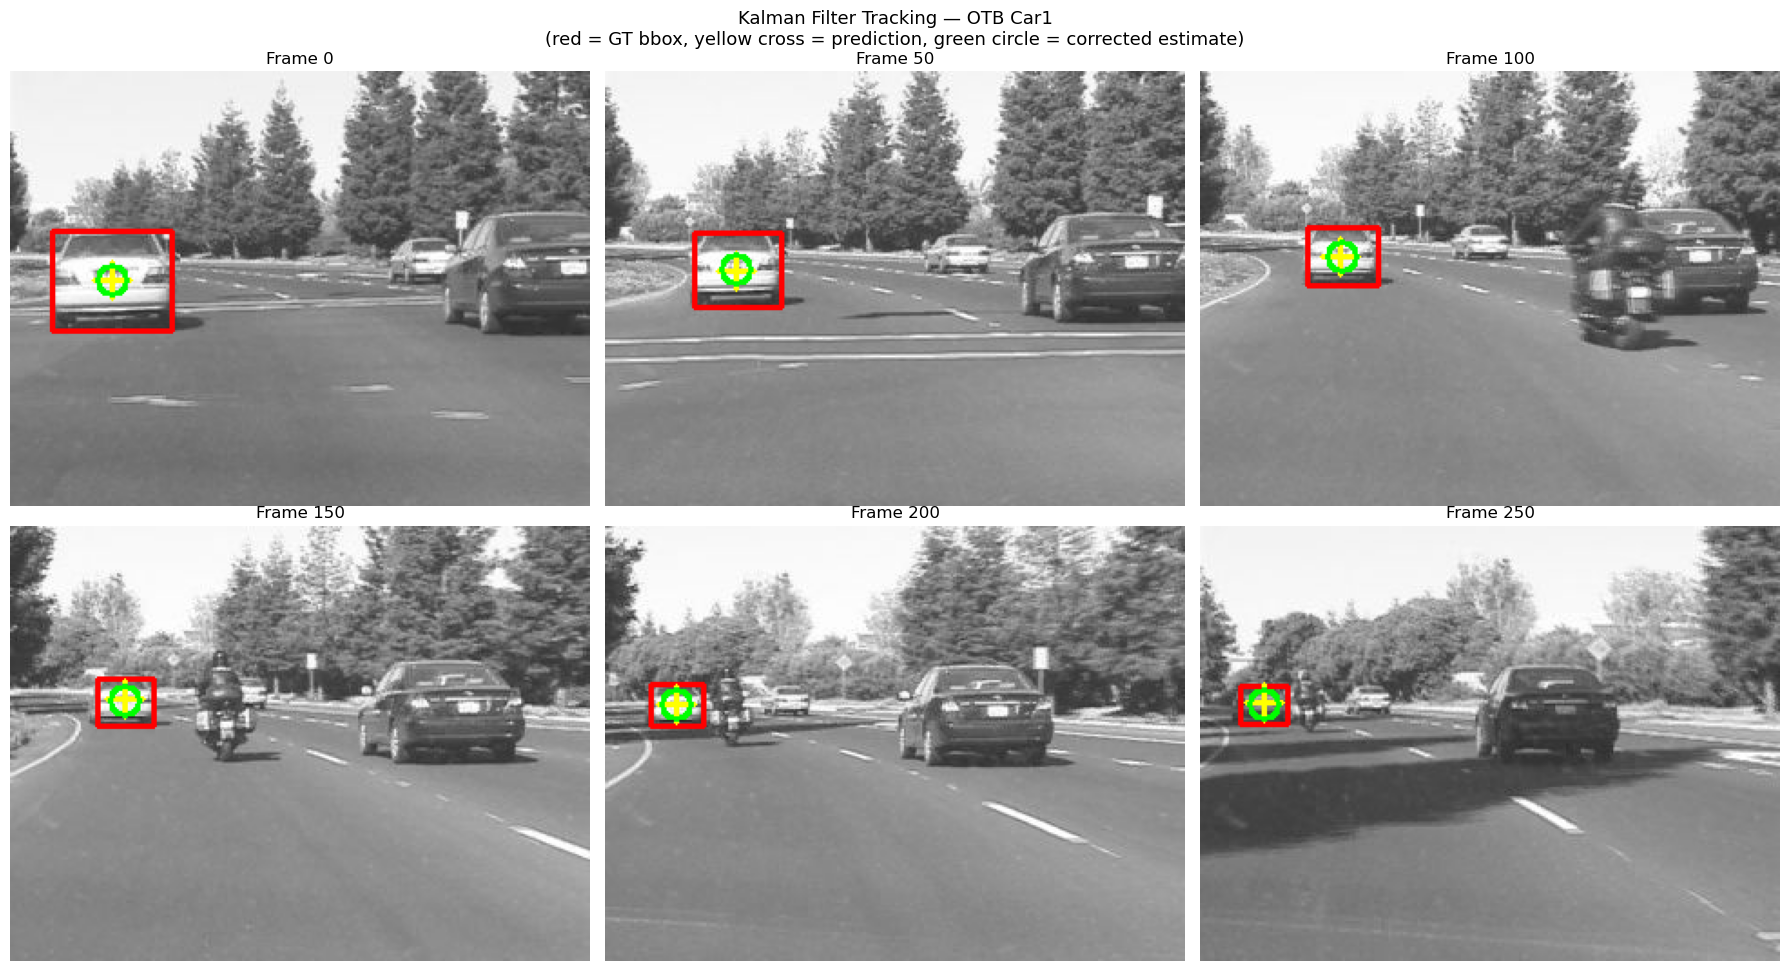

In [4]:
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seq_dir = Path.home() / "data" / "OTB" / "Car1"
frame_paths = sorted((seq_dir / "img").glob("*.jpg"))
lines = (seq_dir / "groundtruth_rect.txt").read_text().strip().split("\n")
gt = np.array([[float(x) for x in re.split(r'[,\t\s]+', line)] for line in lines])

# --- Set up Kalman Filter (4 state vars: x, y, vx, vy; 2 measurements: x, y) ---
kf = cv2.KalmanFilter(4, 2)
kf.measurementMatrix = np.array([[1, 0, 0, 0],
                                  [0, 1, 0, 0]], np.float32)
kf.transitionMatrix = np.array([[1, 0, 1, 0],
                                 [0, 1, 0, 1],
                                 [0, 0, 1, 0],
                                 [0, 0, 0, 1]], np.float32)
kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1

# Initialize with the center of the first GT bbox
x0, y0, w0, h0 = gt[0]
cx0, cy0 = x0 + w0 / 2, y0 + h0 / 2
kf.statePre = np.array([[cx0], [cy0], [0], [0]], np.float32)
kf.statePost = np.array([[cx0], [cy0], [0], [0]], np.float32)

n_frames = min(len(frame_paths), 300)
predictions = []
corrected = []
gt_centers = []

for i in range(n_frames):
    pred = kf.predict()
    predictions.append((float(pred[0, 0]), float(pred[1, 0])))

    # Use GT bbox center as the "detection" (measurement)
    x, y, w, h = gt[i]
    cx, cy = x + w / 2, y + h / 2
    gt_centers.append((cx, cy))

    measurement = np.array([[np.float32(cx)], [np.float32(cy)]])
    corrected_state = kf.correct(measurement)
    corrected.append((float(corrected_state[0, 0]), float(corrected_state[1, 0])))

predictions = np.array(predictions)
corrected = np.array(corrected)
gt_centers = np.array(gt_centers)

# --- Visualize on sampled frames ---
sample_frames = [0, 50, 100, 150, 200, 250]
sample_frames = [f for f in sample_frames if f < n_frames]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, f_idx in zip(axes.flat, sample_frames):
    frame = cv2.cvtColor(cv2.imread(str(frame_paths[f_idx])), cv2.COLOR_BGR2RGB)

    bx, by, bw, bh = gt[f_idx].astype(int)
    cv2.rectangle(frame, (bx, by), (bx+bw, by+bh), (255, 0, 0), 2)

    px, py = predictions[f_idx].astype(int)
    cv2.drawMarker(frame, (px, py), (255, 255, 0), cv2.MARKER_CROSS, 20, 2)

    ex, ey = corrected[f_idx].astype(int)
    cv2.circle(frame, (ex, ey), 8, (0, 255, 0), 2)

    ax.imshow(frame)
    ax.set_title(f"Frame {f_idx}")
    ax.axis("off")

plt.suptitle("Kalman Filter Tracking — OTB Car1\n(red = GT bbox, yellow cross = prediction, green circle = corrected estimate)", fontsize=13)
plt.tight_layout()
plt.show()

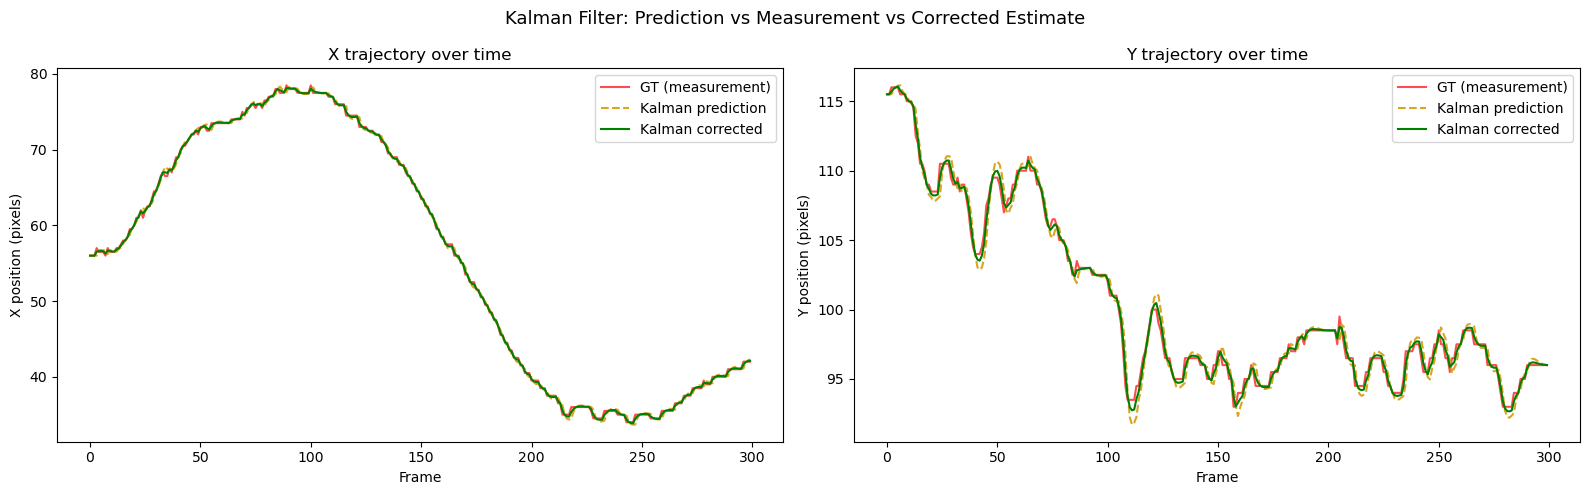

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(gt_centers[:, 0], label="GT (measurement)", color="red", alpha=0.7)
axes[0].plot(predictions[:, 0], label="Kalman prediction", color="goldenrod", linestyle="--")
axes[0].plot(corrected[:, 0], label="Kalman corrected", color="green")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("X position (pixels)")
axes[0].set_title("X trajectory over time")
axes[0].legend()

axes[1].plot(gt_centers[:, 1], label="GT (measurement)", color="red", alpha=0.7)
axes[1].plot(predictions[:, 1], label="Kalman prediction", color="goldenrod", linestyle="--")
axes[1].plot(corrected[:, 1], label="Kalman corrected", color="green")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Y position (pixels)")
axes[1].set_title("Y trajectory over time")
axes[1].legend()

plt.suptitle("Kalman Filter: Prediction vs Measurement vs Corrected Estimate", fontsize=13)
plt.tight_layout()
plt.show()

## Mean-Shift / CAMShift

- Track an object by its **color histogram** distribution
- **Mean-shift**: iteratively finds the mode (densest region) of the color distribution in a search window
- **CAMShift** (Continuously Adaptive Mean-Shift): adapts the window size to the target's scale

**Strengths**: very fast, no learning required

**Weaknesses**: fragile under appearance changes, background clutter, and when multiple objects share similar colors

## CamShift Tracking Demo (OTB Car1) {.scrollable}

CamShift (Continuously Adaptive Mean-Shift) tracks an object by its **color histogram**:

1. Compute the **hue histogram** of the car from the initial bounding box
2. Each frame, **back-project** the histogram onto the frame — pixels similar in color to the car light up
3. Run **CamShift** on the back-projection to find the new position and size of the window

Since it uses color, it works without any motion model — but it breaks when the background has similar colors to the target.

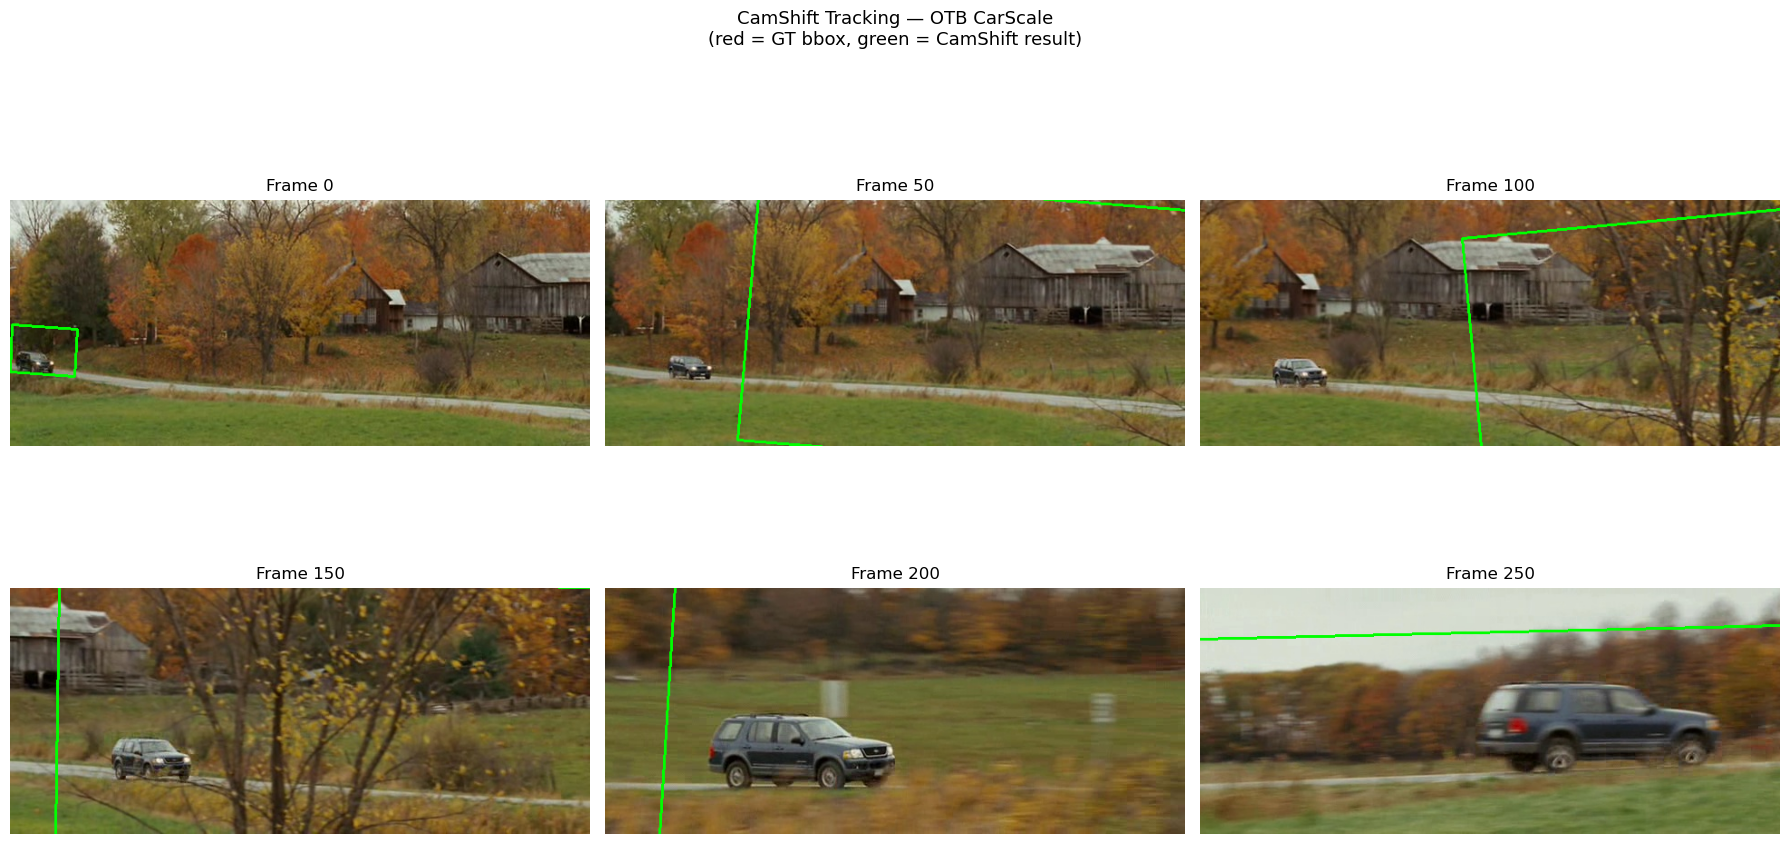

In [2]:
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seq_dir = Path.home() / "data" / "OTB" / "CarScale"
frame_paths = sorted((seq_dir / "img").glob("*.jpg"))
lines = (seq_dir / "groundtruth_rect.txt").read_text().strip().split("\n")
gt = np.array([[float(x) for x in re.split(r'[,\t\s]+', line)] for line in lines])

# Read first frame and set up the initial tracking window
first_frame = cv2.imread(str(frame_paths[0]))
hsv_first = cv2.cvtColor(first_frame, cv2.COLOR_BGR2HSV)
x0, y0, w0, h0 = gt[0].astype(int)
track_window = (x0, y0, w0, h0)

# Compute hue histogram of the car region (color sequence)
roi_hsv = hsv_first[y0:y0+h0, x0:x0+w0]
roi_hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

n_frames = min(len(frame_paths), 252)
camshift_boxes = []

for i in range(n_frames):
    frame = cv2.imread(str(frame_paths[i]))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

    ret, track_window = cv2.CamShift(back_proj, track_window, term_crit)
    pts = cv2.boxPoints(ret)
    camshift_boxes.append((ret, pts))

# Visualize
sample_frames = [0, 50, 100, 150, 200, 250]
sample_frames = [f for f in sample_frames if f < n_frames]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, f_idx in zip(axes.flat, sample_frames):
    frame = cv2.cvtColor(cv2.imread(str(frame_paths[f_idx])), cv2.COLOR_BGR2RGB)

    # # GT bbox (red)
    # bx, by, bw, bh = gt[f_idx].astype(int)
    # cv2.rectangle(frame, (bx, by), (bx+bw, by+bh), (255, 0, 0), 2)

    # CamShift result (green rotated box)
    pts = camshift_boxes[f_idx][1].astype(int)
    cv2.polylines(frame, [pts], True, (0, 255, 0), 2)

    ax.imshow(frame)
    ax.set_title(f"Frame {f_idx}")
    ax.axis("off")

plt.suptitle("CamShift Tracking — OTB CarScale\n(red = GT bbox, green = CamShift result)", fontsize=13)
plt.tight_layout()
plt.show()

## What Does the Car "Look Like" to a Histogram Tracker? {.scrollable}

Mean-shift and CamShift track objects by their **color distribution**. Below we crop the car from the **CarScale** sequence (a true color video) and plot its **hue histogram** at several frames. If the histogram stays stable, CamShift will track well. If lighting or scale changes cause the distribution to shift, tracking degrades.

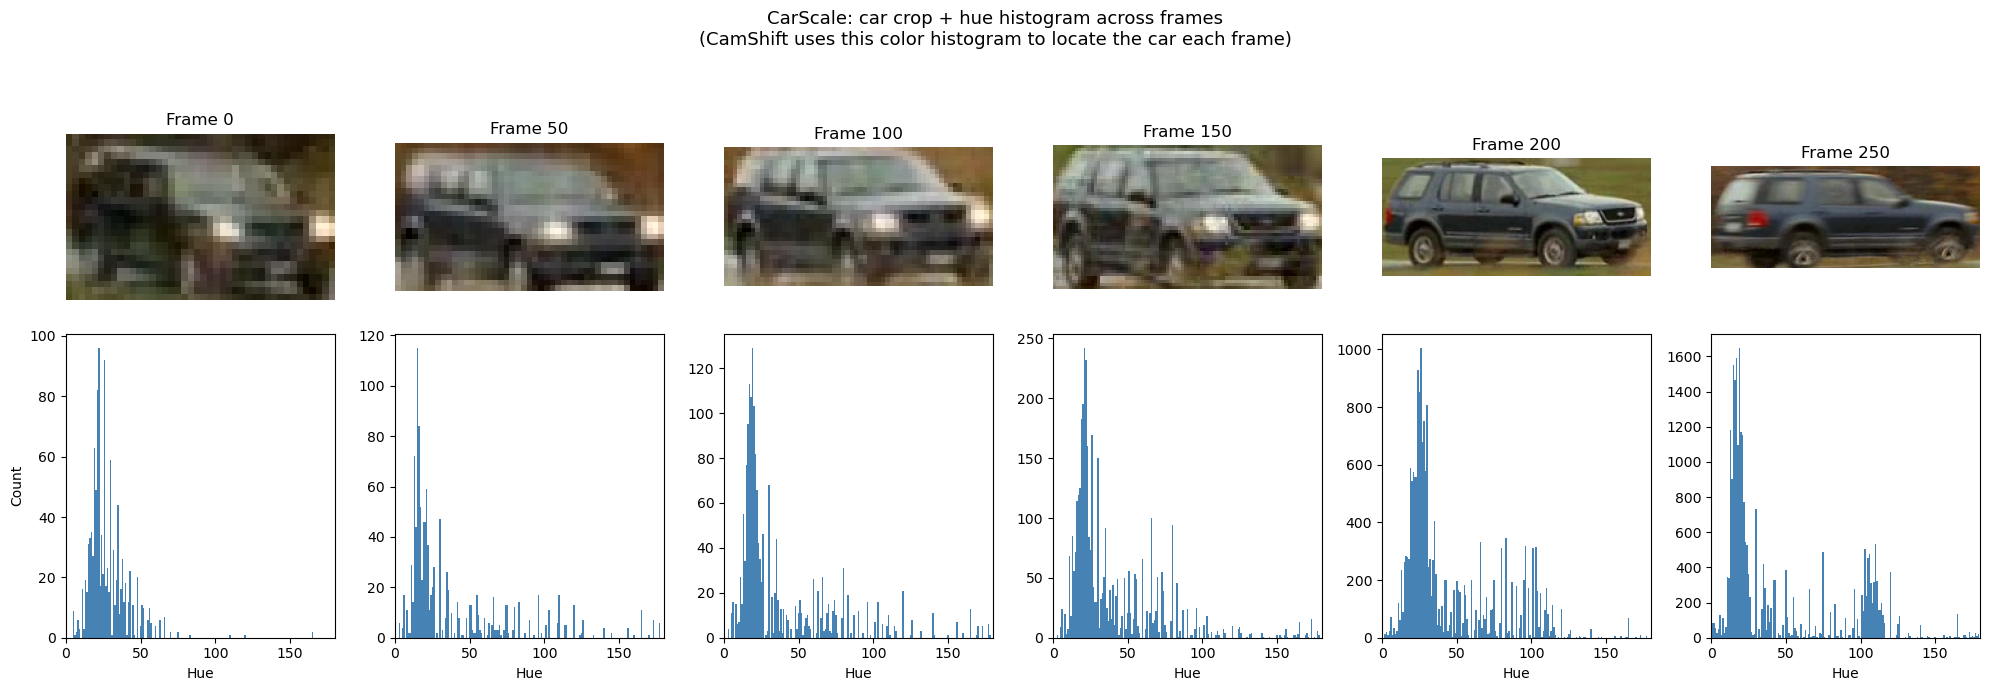

In [1]:
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seq_dir = Path.home() / "data" / "OTB" / "CarScale"
frame_paths = sorted((seq_dir / "img").glob("*.jpg"))
lines = (seq_dir / "groundtruth_rect.txt").read_text().strip().split("\n")
gt = np.array([[float(x) for x in re.split(r'[,\t\s]+', line)] for line in lines])

sample_frames = [0, 50, 100, 150, 200, 250]
sample_frames = [f for f in sample_frames if f < len(frame_paths)]

fig, axes = plt.subplots(2, len(sample_frames), figsize=(20, 7))

for col, f_idx in enumerate(sample_frames):
    frame = cv2.imread(str(frame_paths[f_idx]))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    x, y, w, h = gt[f_idx].astype(int)

    roi_bgr = frame[y:y+h, x:x+w]
    roi_hsv = hsv[y:y+h, x:x+w]

    axes[0, col].imshow(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Frame {f_idx}")
    axes[0, col].axis("off")

    hist = cv2.calcHist([roi_hsv], [0], None, [180], [0, 180])
    axes[1, col].bar(range(180), hist.flatten(), color="steelblue", width=1)
    axes[1, col].set_xlim(0, 180)
    axes[1, col].set_xlabel("Hue")
    axes[1, col].set_ylabel("Count" if col == 0 else "")

plt.suptitle("CarScale: car crop + hue histogram across frames\n(CamShift uses this color histogram to locate the car each frame)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Show what CamShift "sees": the back-projection (histogram matching)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, f_idx in zip(axes.flat, [0, 100, 200]):
    if f_idx >= n_frames:
        continue
    frame = cv2.imread(str(frame_paths[f_idx]))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

    ax.imshow(back_proj, cmap="hot")
    ax.set_title(f"Back-projection — Frame {f_idx}")
    ax.axis("off")

plt.suptitle("CamShift Back-Projection: bright = pixels matching the car's hue histogram", fontsize=13)
plt.tight_layout()
plt.show()

# Tracking-by-Detection: The Modern Paradigm

## Core Idea

Instead of building a tracker from scratch, leverage the strength of modern detectors:

```
Frame_t  →  Detector  →  Bounding Boxes  →  Association  →  Tracks
```

1. Run a detector (Faster R-CNN, YOLO, etc.) on **every frame independently**
2. **Associate** detections across frames to form tracks

This decouples *"what is there?"* from *"who is who?"*

**Why this dominates today**:

- Detectors are already very good — no need to reinvent that wheel
- Modular: swap detectors or association methods independently
- Scales naturally to many objects

## The Association Problem

Given $N$ detections in frame $t$ and $M$ existing tracks from frame $t-1$, find the **best assignment**.

This is a **bipartite matching** problem:

- Each detection should be assigned to at most one track
- Each track should be assigned to at most one detection
- Some detections may be **new objects** (start a new track)
- Some tracks may have **no matching detection** (object is occluded or left the frame)

**Matching cues**:

- **Motion**: predicted position from Kalman filter vs detection position
- **Appearance**: visual similarity (embeddings)
- **Geometry**: bounding box size and aspect ratio

## Hungarian Algorithm

The Hungarian algorithm solves the **assignment problem**: given $M$ workers and $N$ jobs, each with a cost, find the one-to-one assignment that minimizes total cost.

**Steps:**

1. Build a **cost matrix** $C$ where $C_{i,j}$ = cost of assigning worker $i$ to job $j$
2. **Row reduction**: subtract each row's minimum from that row
3. **Column reduction**: subtract each column's minimum from that column
4. Try to assign one zero per row/column. If not possible, adjust the matrix and repeat.
5. Result: the **globally optimal** one-to-one assignment in $O(n^3)$ time

```python
from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(cost_matrix)
```

## Hungarian Algorithm for Tracking

### Where do the two sets of boxes come from?

No ground truth is involved at runtime. The IoU is computed between two sets of boxes that the system generates itself:

- **Rows (tracks)**: each existing track has a **Kalman filter** that *predicts* a bounding box for the current frame — "where I expect this object to be now"
- **Columns (detections)**: a **detector** (YOLO, Faster R-CNN, etc.) runs on the current frame and outputs bounding boxes — "what I actually see right now"

| Source | Box | Bbox $(x, y, w, h)$ |
|--------|-----|---------------------|
| Kalman predict | Track 0 | (120, 80, 60, 45) |
| Kalman predict | Track 1 | (300, 150, 50, 40) |
| Kalman predict | Track 2 | (50, 200, 40, 35) |
| **YOLO detector** | **Det 0** | **(125, 82, 58, 44)** |
| **YOLO detector** | **Det 1** | **(305, 148, 52, 42)** |
| **YOLO detector** | **Det 2** | **(48, 198, 42, 37)** |
| **YOLO detector** | **Det 3** | **(500, 100, 30, 30)** |

```{mermaid}
flowchart LR
    A["Kalman predictions<br/>(3 track boxes)"] --> C["Compute IoU<br/>between all pairs"]
    B["YOLO detections<br/>(4 detection boxes)"] --> C
    C --> D["Cost matrix<br/>C = 1 − IoU"]
    D --> E["Hungarian<br/>Algorithm"]
    E --> F["Track–detection<br/>assignments"]

    style A fill:#4a90d9,color:#fff,stroke:#2c5f8a
    style B fill:#f5a623,color:#fff,stroke:#c47d12
    style C fill:#9b59b6,color:#fff,stroke:#6c3483
    style D fill:#9b59b6,color:#fff,stroke:#6c3483
    style E fill:#7ed321,color:#fff,stroke:#5a9a18
    style F fill:#9b9b9b,color:#fff,stroke:#6b6b6b
```

### Building and solving the cost matrix

Compute IoU between every predicted track box and every detection box:

|  | Det 0 | Det 1 | Det 2 | Det 3 |
|--|-------|-------|-------|-------|
| **Track 0** | 0.82 | 0.05 | 0.10 | 0.01 |
| **Track 1** | 0.03 | 0.71 | 0.02 | 0.08 |
| **Track 2** | 0.01 | 0.04 | 0.65 | 0.12 |

Convert to cost: $C_{i,j} = 1 - \text{IoU}_{i,j}$ (minimize cost = maximize overlap). Hungarian solves this:

- Track 0 → Det 0 (IoU 0.82) — the predicted box was close to the detection
- Track 1 → Det 1 (IoU 0.71)
- Track 2 → Det 2 (IoU 0.65)
- Det 3 has **no matching track** → start a new track (new object entered the scene)

Ground truth is only used during **evaluation** (MOTA, IDF1), never during tracking itself.

## Hungarian Algorithm Demo {.scrollable}

Optimal assignment (Hungarian algorithm):
  Track 0 -> Detection 0  (IoU = 0.82)
  Track 1 -> Detection 1  (IoU = 0.71)
  Track 2 -> Detection 2  (IoU = 0.65)

Detection 3 is unmatched -> start a new track


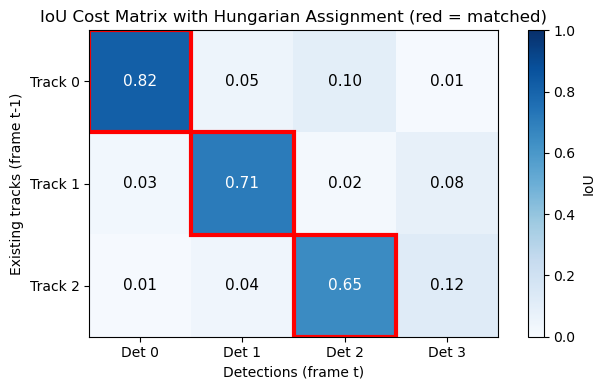

In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib.patches as patches

iou_matrix = np.array([
    [0.82, 0.05, 0.10, 0.01],
    [0.03, 0.71, 0.02, 0.08],
    [0.01, 0.04, 0.65, 0.12],
])

cost_matrix = 1 - iou_matrix
row_ind, col_ind = linear_sum_assignment(cost_matrix)

print("Optimal assignment (Hungarian algorithm):")
for r, c in zip(row_ind, col_ind):
    print(f"  Track {r} -> Detection {c}  (IoU = {iou_matrix[r, c]:.2f})")
print(f"\nDetection 3 is unmatched -> start a new track")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(iou_matrix, cmap='Blues', vmin=0, vmax=1)

for i in range(iou_matrix.shape[0]):
    for j in range(iou_matrix.shape[1]):
        ax.text(j, i, f'{iou_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=11,
                color='white' if iou_matrix[i, j] > 0.5 else 'black')

for r, c in zip(row_ind, col_ind):
    rect = patches.Rectangle((c - 0.5, r - 0.5), 1, 1,
                             fill=False, edgecolor='red', linewidth=3)
    ax.add_patch(rect)

ax.set_xticks(range(4))
ax.set_xticklabels([f'Det {i}' for i in range(4)])
ax.set_yticks(range(3))
ax.set_yticklabels([f'Track {i}' for i in range(3)])
ax.set_xlabel('Detections (frame t)')
ax.set_ylabel('Existing tracks (frame t-1)')
ax.set_title('IoU Cost Matrix with Hungarian Assignment (red = matched)')
plt.colorbar(im, ax=ax, label='IoU')
plt.tight_layout()
plt.show()

# SORT: Simple Online and Realtime Tracking

## SORT Pipeline

[*Bewley et al., 2016*](https://arxiv.org/pdf/1602.00763){target="_blank"}

SORT is not a detector — it's the **glue** that turns per-frame detections into consistent tracks over time. It takes any off-the-shelf detector (YOLO, Faster R-CNN, etc.) as input and adds two things on top:

- A **Kalman filter** per track — to predict where each object will be in the next frame
- The **Hungarian algorithm** — to match those predictions to new detections

The Hungarian algorithm alone only solves one frame's assignment. SORT wraps it in a **loop with memory**: it maintains track states across frames, predicts forward, and manages track creation/deletion.

### The loop (every frame)

1. **Detect**: run an external detector on frame $t$ → get bounding boxes
2. **Predict**: each existing track's Kalman filter predicts its bbox for frame $t$
3. **Associate**: compute IoU between predicted boxes and detected boxes → Hungarian algorithm finds the optimal assignment
4. **Update**:
   - Matched tracks → Kalman **correct** (blend prediction with detection)
   - Unmatched detections → **new track** (object just appeared)
   - Unmatched tracks → **age out** after $T_{\text{lost}}$ frames (object left or occluded too long)

No appearance model — SORT only uses **position and motion**. That's what makes it fast (~260 FPS for the tracking part alone), but also why it fails when similar objects cross paths.

## SORT: Strengths and Weaknesses

**Strengths**:

- Very fast (~260 FPS for association alone)
- Simple to implement and understand
- Works well when objects move predictably and don't overlap much

**Weaknesses**:

- **No appearance model** — the tracker cannot distinguish between similar-looking objects
- Lots of **ID switches** when objects occlude or cross paths
- If two people walk past each other, their IoU-based association gets confused

This motivates DeepSORT: we need a way to tell objects *apart* beyond just position.

# DeepSORT

## The Re-ID Embedding

*Wojke, Bewley, & Paulus, 2017*

The key addition: a **re-identification (Re-ID) network**

- A small CNN that takes a crop of a detected object and produces a **feature embedding** (a vector)
- Objects that look similar have **nearby embeddings** in this space
- Trained on re-identification datasets (e.g., Market-1501, CUHK03)

Now we can compare objects not just by *where they are* but by *what they look like*.

## DeepSORT Pipeline

1. **Detect** → bounding boxes
2. **Extract appearance** → run each detection crop through the Re-ID CNN → feature embedding
3. **Predict** → Kalman predict for each existing track
4. **Associate** → cascaded matching using **both** motion and appearance costs
5. **Update** → Kalman update for matched tracks

```
Detect → Re-ID CNN → Kalman Predict → Cascaded Matching → Update
```

## DeepSORT: Motion + Appearance Association

The association cost combines two signals:

$$C = \lambda_1 \cdot d_{\text{motion}} + \lambda_2 \cdot d_{\text{appearance}}$$

- **Motion gate** ($d_{\text{motion}}$): Mahalanobis distance from the Kalman filter
  - "Is this detection where I predicted the track would be?"
- **Appearance distance** ($d_{\text{appearance}}$): Cosine distance between Re-ID embeddings
  - "Does this detection *look like* the object I'm tracking?"

**Cascade matching**: prioritize recently seen tracks over older ones — recently seen tracks have more reliable appearance information.

## SORT vs DeepSORT

| | SORT | DeepSORT |
|---|------|----------|
| **Motion model** | Kalman filter | Kalman filter |
| **Appearance model** | None | Re-ID CNN |
| **Association** | IoU + Hungarian | Motion + appearance + cascade |
| **ID switches** | Many (in crowded scenes) | Far fewer |
| **Speed** | Very fast | Slower (Re-ID adds overhead) |
| **Best for** | Simple scenes | Crowded scenes, frequent occlusion |

# Siamese Trackers (Single-Object Tracking)

## SiamFC: Template Matching via Cross-Correlation

*Bertinetto et al., 2016*

**Core idea**: track a single object by matching a **template** to a **search region**.

1. **Frame 1**: crop the target → extract features with a CNN → this is the *template*
2. **Frame $t$**: extract a larger search region around the last known location → extract features
3. **Cross-correlate** template features with search features → produces a **similarity heatmap**
4. Peak of the heatmap = predicted target location

The two CNN branches share weights (hence *Siamese*) — the network learns a general similarity function.

**Strengths**: fast, simple, no online training needed

**Limitations**: single-object only; no online model update in the basic form → can drift on long sequences

**Modern extensions**: SiamRPN (adds bounding box regression), SiamMask (adds segmentation)

# Modern Trackers

## ByteTrack

[*Zhang et al., 2022*](https://arxiv.org/pdf/2110.06864){target="_blank"}

**Key insight**: don't throw away low-confidence detections — they often correspond to **occluded objects** that are still present but harder to see.

**Two-stage association**:

1. First match existing tracks to **high-confidence** detections (as usual)
2. Then match **remaining unmatched tracks** to **low-confidence** detections

This simple change yields state-of-the-art results with *any* detector and *no* appearance model.

**Takeaway**: a better association strategy can matter more than a fancier model.

## Joint Detection and Tracking

Instead of running detection and tracking as separate steps, predict detections **and** track embeddings in **one forward pass**.

- **FairMOT**: adds a Re-ID branch to CenterNet (anchor-free detector)
- **CenterTrack**: detects objects in the current frame conditioned on the previous frame
- **JDE** (Joint Detection and Embedding): shared backbone for detection + Re-ID

**Advantage**: faster (shared computation), tighter integration

**Disadvantage**: harder to train — optimizing for detection and Re-ID simultaneously can create conflicting gradients

## Transformer-based Tracking

- **TrackFormer**, **MOTR**: use transformer decoders where each *query* represents a track
- Object queries **persist across frames** — tracking becomes sequence modeling
- The attention mechanism naturally models **interactions between objects** (e.g., "these two objects are about to occlude each other")

**Promising** but computationally expensive — not yet practical for real-time applications on resource-constrained devices.

[![](./img/motr.png)](https://arxiv.org/pdf/2105.03247#page=2){target="_blank"}

# MOT Evaluation Metrics

## MOTA, MOTP, IDF1, and ID Switches {.scrollable}

### MOTA (Multiple Object Tracking Accuracy)

$$\text{MOTA} = 1 - \frac{\text{FN} + \text{FP} + \text{IDSW}}{\text{GT}}$$

- Penalizes missed detections (FN), false alarms (FP), and identity switches (IDSW)
- Can be **negative** if errors exceed the ground truth count
- Dominated by detection quality (FN and FP are usually the largest terms)

### MOTP (Multiple Object Tracking Precision)

- Average IoU between matched tracks and ground truth
- Measures **localization** quality, not association quality

### IDF1

- Harmonic mean of identification precision and recall
- Better at capturing **identity consistency** than MOTA
- "Of all the detections assigned to a track, what fraction truly belong to one identity?"

### ID Switches (IDSW)

- Number of times a track's assigned identity changes mid-sequence
- Directly measures **association failure**

### Comparison

| Metric | Measures | Sensitive to |
|--------|----------|-------------|
| MOTA   | Overall accuracy | Detection quality + ID switches |
| MOTP   | Localization | Bounding box precision |
| IDF1   | Identity consistency | Association quality |
| IDSW   | Re-ID failures | Occlusion + crowding |

# Failure Modes

## Common Tracking Failures

- **Occlusion**: an object temporarily disappears behind another object or behind the frame edge. The tracker loses the target or assigns the wrong ID when it reappears.

- **Re-identification failure**: after an occlusion event, the tracker assigns a **new ID** to the same object instead of reconnecting to the original track.

- **Drift** (especially in SOT): the tracker gradually slides off the target over time as small errors accumulate frame-to-frame.

- **ID switches in crowds**: when similar-looking objects are in close proximity, the tracker swaps their identities — Person A becomes Person B and vice versa.

Understanding these failures is critical for choosing the right tracker and interpreting evaluation metrics.

# Practical Considerations

## Choosing a Tracker

| Scenario | Recommended |
|----------|------------|
| Few objects, predictable motion | SORT |
| Crowded scenes, frequent occlusion | DeepSORT or ByteTrack |
| Real-time on edge device | SORT or ByteTrack (no Re-ID overhead) |
| Research / best accuracy | Transformer-based (TrackFormer, MOTR) |
| Single-object tracking | Siamese tracker (SiamFC / SiamRPN) |

**Common pitfalls**:

- Tracking quality is **bottlenecked by detection quality** — improve the detector first
- **Frame rate matters**: at low FPS, objects move more between frames → association is harder
- **Camera motion** can be handled with ego-motion compensation, but adds complexity
- **Re-ID models don't generalize** across domains — a pedestrian Re-ID model won't work for vehicles

## Connection to Course Projects

- Object tracking is listed as an **advanced extension** for Project Check-In 3
- Natural fit if your project involves **video data** (surveillance, sports, traffic, etc.)
- You would add tracking **on top of** your detection baseline from earlier check-ins
- Example pipeline: YOLO detector (from Week 8) + SORT/DeepSORT tracker = full MOT system

# Demo: Tracking an Object Across Frames

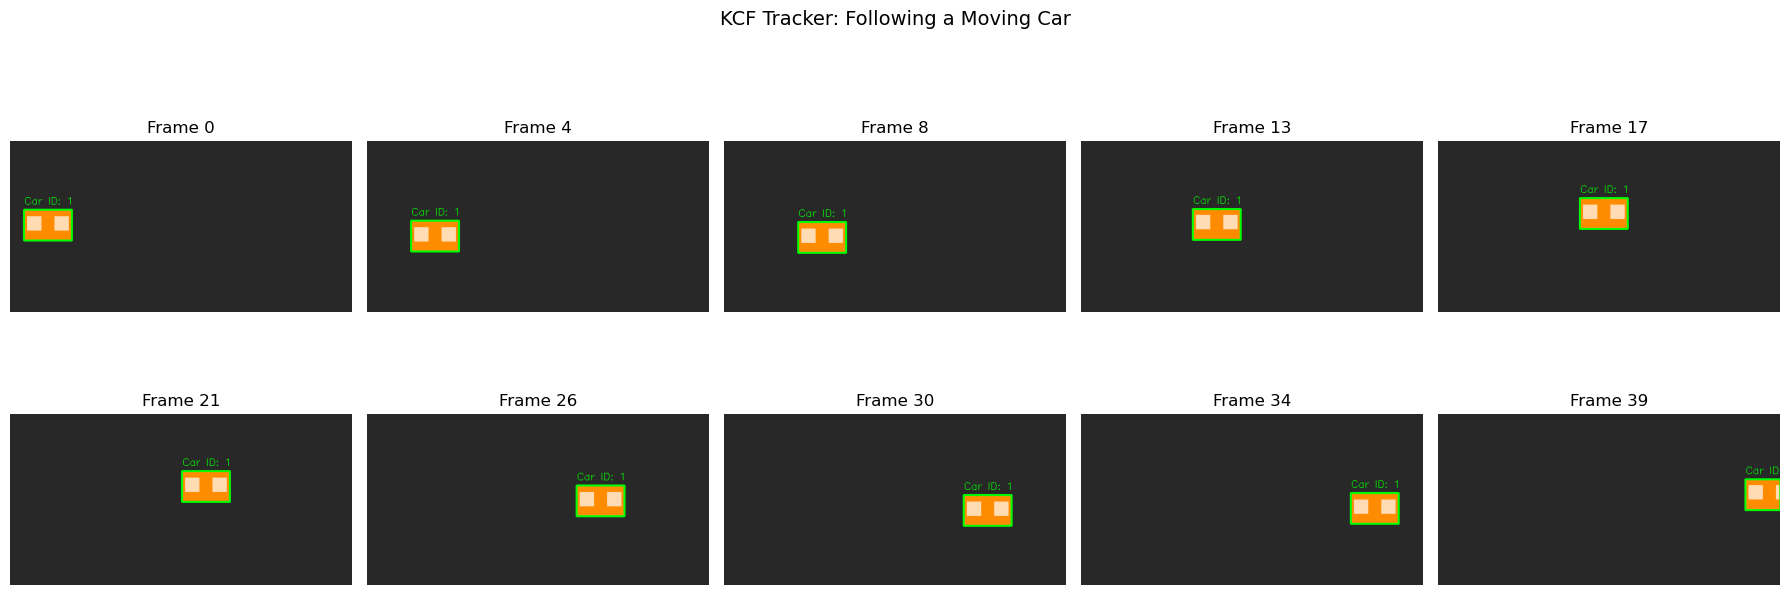

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

n_frames = 40
H, W = 250, 500
frames = []
for i in range(n_frames):
    frame = np.full((H, W, 3), 40, dtype=np.uint8)
    x = 20 + i * 11
    y = 100 + int(20 * np.sin(i * 0.25))
    cv2.rectangle(frame, (x, y), (x + 70, y + 45), (0, 140, 255), -1)
    cv2.rectangle(frame, (x + 5, y + 10), (x + 25, y + 30), (180, 220, 255), -1)
    cv2.rectangle(frame, (x + 45, y + 10), (x + 65, y + 30), (180, 220, 255), -1)
    frames.append(frame)

tracker = cv2.TrackerKCF.create()
init_bbox = (20, 100, 70, 45)
tracker.init(frames[0], init_bbox)

tracked_frames = []
trajectory = []
for i, frame in enumerate(frames):
    success, bbox = tracker.update(frame)
    display = frame.copy()
    if success:
        x, y, w, h = [int(v) for v in bbox]
        cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(display, 'Car ID: 1', (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        trajectory.append((x + w // 2, y + h // 2))
    tracked_frames.append(display)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
sample_idx = np.linspace(0, n_frames - 1, 10, dtype=int)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(cv2.cvtColor(tracked_frames[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {idx}')
    ax.axis('off')
plt.suptitle('KCF Tracker: Following a Moving Car', fontsize=14)
plt.tight_layout()
plt.show()

## Trajectory Visualization {.scrollable}

In [ ]:
if trajectory:
    traj = np.array(trajectory)
    canvas = np.full((H, W, 3), 40, dtype=np.uint8)
    for j in range(1, len(traj)):
        color_val = int(255 * j / len(traj))
        cv2.line(canvas,
                 tuple(traj[j - 1]), tuple(traj[j]),
                 (0, color_val, 255 - color_val), 2)
    cv2.circle(canvas, tuple(traj[0]), 6, (0, 255, 0), -1)
    cv2.circle(canvas, tuple(traj[-1]), 6, (0, 0, 255), -1)

    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title('Tracked Trajectory (green = start, red = end)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Key Takeaways

1. Tracking = detection + **data association** across time
2. The Kalman filter provides a **motion prior** — predict where an object will be, correct when you see it
3. The Hungarian algorithm solves **optimal assignment** between tracks and detections
4. **SORT** = Kalman + Hungarian (fast, simple, fragile on occlusion)
5. **DeepSORT** adds **appearance embeddings** (Re-ID CNN) to reduce ID switches
6. **Siamese trackers** (SiamFC) handle single-object tracking via template cross-correlation
7. **ByteTrack** shows that keeping low-confidence detections is a surprisingly powerful trick
8. Evaluation: **MOTA** captures overall quality; **IDF1** captures identity consistency
9. In practice, **detection quality is the bottleneck** — improve the detector before tuning the tracker

# Study Guide

## Tracking Fundamentals {.scrollable}

**Topics to review:**

- Difference between detection and tracking
- Single-object tracking (SOT) vs multi-object tracking (MOT)
- Key challenges: occlusion, appearance change, camera motion, scale change, crowding

**Example questions:**

- What information does a tracker provide that a detector alone does not?
- Why is MOT harder than SOT?
- Name three challenges that make object tracking difficult.

## Classical Tracking {.scrollable}

**Topics to review:**

- Optical flow: brightness constancy assumption, Lucas-Kanade vs Farneback
- Kalman filter: state vector, predict step, update step, assumptions (linear motion, Gaussian noise)
- Mean-shift / CAMShift: color histogram tracking, limitations

**Example questions:**

- What assumption underlies optical flow? When does it break down?
- Describe the two steps of the Kalman filter and what each one does.
- What happens to a Kalman filter's predictions during an occlusion (no detection available)?

## Tracking-by-Detection {.scrollable}

**Topics to review:**

- The tracking-by-detection paradigm: detect per frame, then associate
- The association problem as bipartite matching
- Hungarian algorithm: what it solves, what the cost matrix represents

**Example questions:**

- Why is tracking-by-detection the dominant modern approach?
- What does the cost matrix in the Hungarian algorithm represent in the context of tracking?
- What happens to unmatched detections? What about unmatched tracks?

## SORT and DeepSORT {.scrollable}

**Topics to review:**

- SORT pipeline: detect → Kalman predict → IoU matching (Hungarian) → update
- SORT limitations: no appearance model → ID switches
- DeepSORT addition: Re-ID CNN for appearance embeddings
- DeepSORT cost function: motion (Mahalanobis distance) + appearance (cosine distance)
- Cascade matching: prioritize recently seen tracks

**Example questions:**

- What two components make up SORT? Why is it fast?
- Why does SORT produce many ID switches in crowded scenes?
- What does the Re-ID network in DeepSORT do?
- Explain the difference between the motion and appearance terms in DeepSORT's cost function.

## Siamese Trackers {.scrollable}

**Topics to review:**

- SiamFC: template from frame 1, search region in frame $t$, cross-correlation
- Why it's called "Siamese" (twin branches with shared weights)
- Strengths (fast, simple) and limitations (drift, no online update)

**Example questions:**

- How does SiamFC locate the target in a new frame?
- Why might a Siamese tracker drift over a long video?

## Modern Methods {.scrollable}

**Topics to review:**

- ByteTrack: using low-confidence detections for occluded objects
- Joint detection and tracking: FairMOT, CenterTrack
- Transformer-based tracking: queries as persistent tracks

**Example questions:**

- What is ByteTrack's key insight about low-confidence detections?
- What is the advantage of joint detection and tracking over tracking-by-detection?
- How do transformer-based trackers represent tracks?

## Evaluation Metrics {.scrollable}

**Topics to review:**

- MOTA: formula, what it penalizes, can be negative
- MOTP: localization quality
- IDF1: identity consistency
- ID switches: direct measure of association failure

**Example questions:**

- Write the MOTA formula and explain each term.
- Why can MOTA be negative?
- Which metric best captures identity consistency: MOTA or IDF1? Why?
- A tracker has high MOTA but many ID switches. What does this tell you?